# Análise de Sentimentos com NLP
## Classificação de Revisões do IMDB

**Dataset**: IMDB Movie Reviews - 50.000 revisões balanceadas (25.000 positivas, 25.000 negativas)


- **Bag of Words (BoW)**: Representação baseada em contagem de palavras
- **TF-IDF**: Representação que pondera a importância das palavras



In [94]:
import os
import numpy as np
import pandas as pd

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, accuracy_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


import matplotlib.pyplot as plt


In [60]:
def carregar_dados(base_path):
    textos = []
    labels = []

    for label, sentimento in enumerate(["neg", "pos"]):
        caminho = os.path.join(base_path, sentimento)

        for arquivo in os.listdir(caminho):
            if arquivo.endswith(".txt"):
                with open(os.path.join(caminho, arquivo), encoding="utf-8") as f:
                    textos.append(f.read())
                    labels.append(label)

    return textos, labels


In [61]:
X_train, y_train = carregar_dados("../data/raw/imdb/train")
X_test, y_test = carregar_dados("../data/raw/imdb/test")

print("Treino:", len(X_train))
print("Teste:", len(X_test))

Treino: 25000
Teste: 25000


## Bag of Words

In [ ]:
vectorizer_bow = CountVectorizer(
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.9,
    stop_words='english'

)

X_train_bow = vectorizer_bow.fit_transform(X_train)
X_test_bow = vectorizer_bow.transform(X_test)

Dimensão BoW: (25000, 81097)


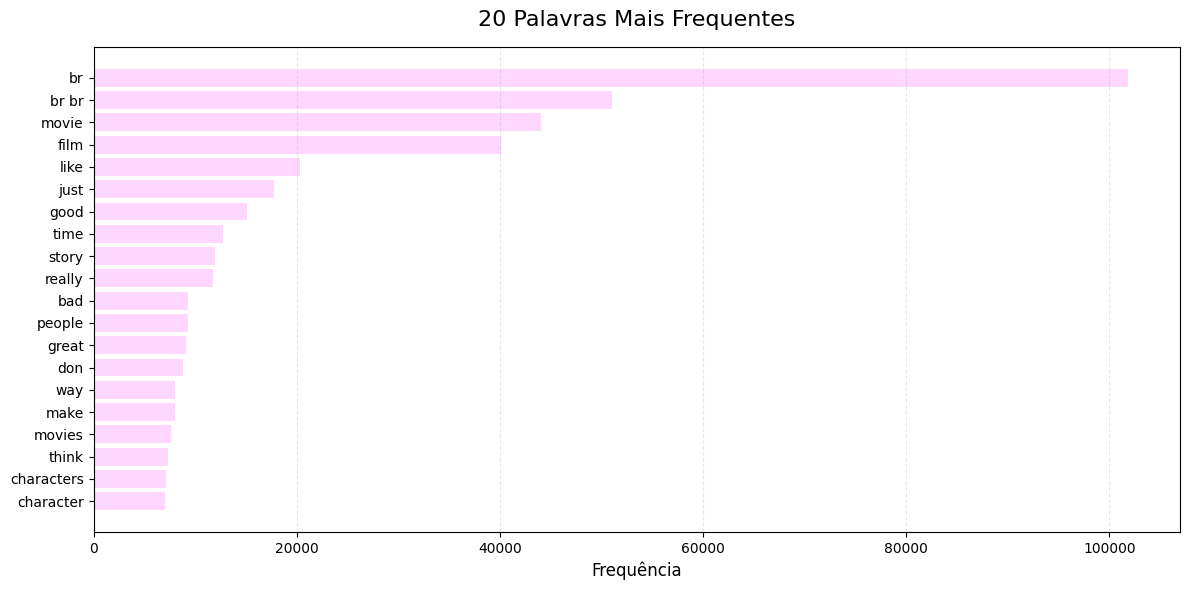

In [63]:
# Soma as ocorrências de cada palavra
word_counts = np.array(X_train_bow.sum(axis=0)).flatten()
words = vectorizer_bow.get_feature_names_out()

top_n = 20
top_indices = np.argsort(word_counts)[-top_n:]
top_words = [words[i] for i in top_indices]
top_counts = word_counts[top_indices]

plt.figure(figsize=(12, 6))
bars = plt.barh(range(top_n), top_counts, color='#ffd6ff', linewidth=0.8)
plt.yticks(range(top_n), top_words)
plt.xlabel('Frequência', fontsize=12)
plt.title(f'{top_n} Palavras Mais Frequentes', fontsize=16, pad=15)
plt.grid(axis='x', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

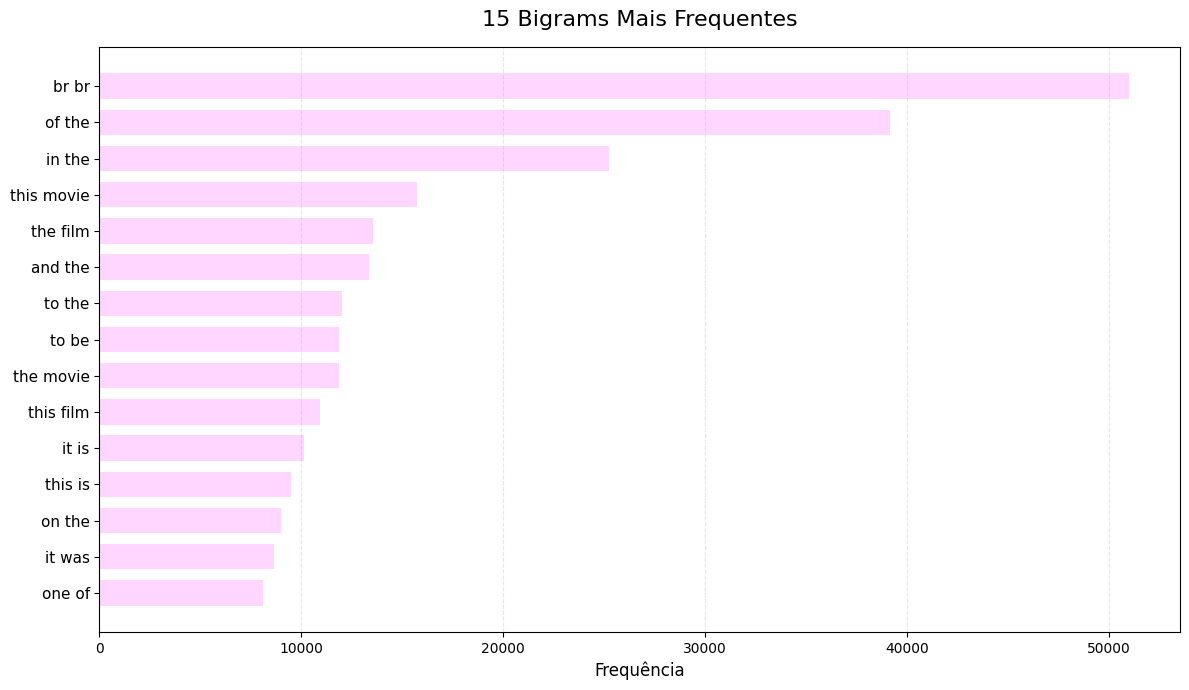

Total de bigrams únicos: 129549
Bigrams com frequência >= 5: 129549


In [64]:
vectorizer_bigrams = CountVectorizer(ngram_range=(2, 2), min_df=5)
X_bigrams = vectorizer_bigrams.fit_transform(X_train)
bigram_counts = np.array(X_bigrams.sum(axis=0)).flatten()
bigrams = vectorizer_bigrams.get_feature_names_out()

top_n_bigrams = 15  
top_bigrams_idx = np.argsort(bigram_counts)[-top_n_bigrams:]
top_bigrams = [bigrams[i] for i in top_bigrams_idx]
top_bigram_counts = bigram_counts[top_bigrams_idx]

plt.figure(figsize=(12, 7))

bars = plt.barh(range(len(top_bigrams)), top_bigram_counts, 
                color='#ffd6ff', 
                linewidth=0.8,
                height=0.7)

plt.yticks(range(len(top_bigrams)), top_bigrams, fontsize=11)
plt.xlabel('Frequência', fontsize=12)
plt.title(f'{len(top_bigrams)} Bigrams Mais Frequentes', fontsize=16, pad=15)
plt.grid(axis='x', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

print(f"Total de bigrams únicos: {len(bigrams)}")
print(f"Bigrams com frequência >= 5: {np.sum(bigram_counts >= 5)}")

Número de palavras no vocabulário: 81097
Shape do word_counts: (81097,)


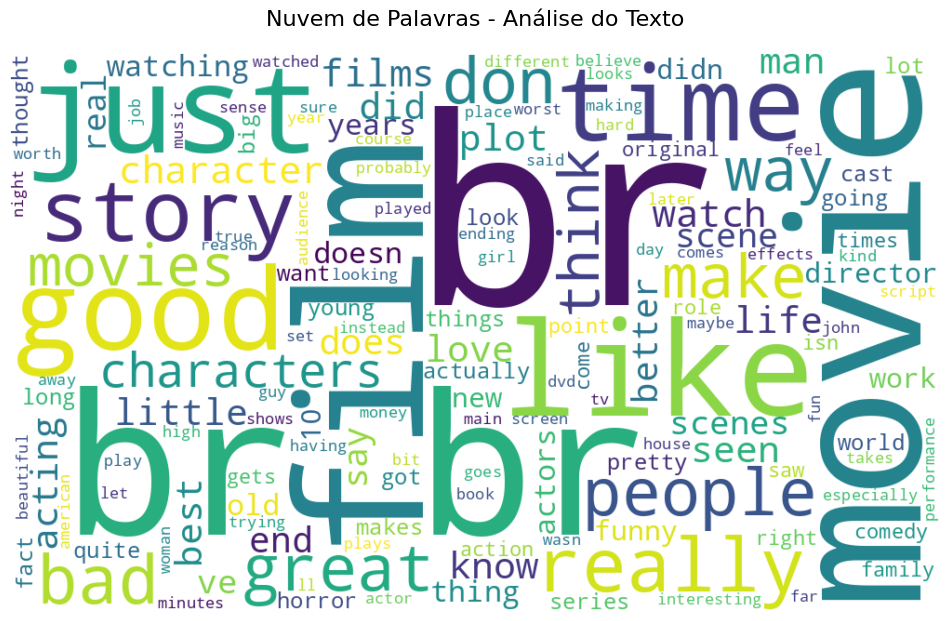

In [65]:
from wordcloud import WordCloud

words = vectorizer_bow.get_feature_names_out()  
word_counts = np.array(X_train_bow.sum(axis=0)).flatten()  

print(f"Número de palavras no vocabulário: {len(words)}")
print(f"Shape do word_counts: {word_counts.shape}")

freq_dict = dict(zip(words, word_counts))

plt.figure(figsize=(12, 8))
wordcloud = WordCloud(
    width=1000, 
    height=600,
    background_color='white',
    max_words=150,
    colormap='viridis',
    contour_width=1,
    contour_color='steelblue'
).generate_from_frequencies(freq_dict)

plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Nuvem de Palavras - Análise do Texto', fontsize=16, pad=20)
plt.show()

In [ ]:
cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

## 1. Regressão Logística (BoW)

In [ ]:
pipeline_lr_bow = Pipeline([
    ("vect", CountVectorizer(ngram_range=(1,2), min_df=5, max_df=0.9)),
    ("clf", LogisticRegression(max_iter=1000))
])

param_grid_lr_bow = {
    "vect__ngram_range": [(1,1), (1,2)],
    "vect__min_df": [5, 10],
    "vect__max_df": [0.9, 0.95]
}

grid_lr_bow = GridSearchCV(
    pipeline_lr_bow,
    param_grid_lr_bow,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

grid_lr_bow.fit(X_train, y_train)

print("Melhores parâmetros (Logistic Regression + BoW):", grid_lr_bow.best_params_)

Melhores parâmetros (Logistic Regression + BoW): {'vect__max_df': 0.9, 'vect__min_df': 5, 'vect__ngram_range': (1, 2)}


In [67]:
y_pred_lr_bow = grid_lr_bow.predict(X_test)

print("Acurácia:", accuracy_score(y_test, y_pred_lr_bow))
print(classification_report(y_test, y_pred_lr_bow))

Acurácia: 0.8936
              precision    recall  f1-score   support

           0       0.89      0.89      0.89     12500
           1       0.89      0.89      0.89     12500

    accuracy                           0.89     25000
   macro avg       0.89      0.89      0.89     25000
weighted avg       0.89      0.89      0.89     25000



## 2. LinearSVM (BoW)

In [ ]:
pipeline_svc_bow = Pipeline([
        ("vect", CountVectorizer(ngram_range=(1,2), min_df=5, max_df=0.9)),
        ("clf", LinearSVC())
])

param_grid_svc_bow = {
    "vect__ngram_range": [(1,1), (1,2)],
    "vect__min_df": [5, 10],
    "vect__max_df": [0.9],
    "clf__C": [0.1, 1, 10]
}

grid_svc_bow = GridSearchCV(
    pipeline_svc_bow,
    param_grid_svc_bow,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

grid_svc_bow.fit(X_train, y_train)

print("Melhores parâmetros (LinearSVC + BoW):")
print(grid_svc_bow.best_params_)


/home/enginelab/Documentos/repos/projeto-ciencia-dos-dados/venv/lib/python3.12/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/enginelab/Documentos/repos/projeto-ciencia-dos-dados/venv/lib/python3.12/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/enginelab/Documentos/repos/projeto-ciencia-dos-dados/venv/lib/python3.12/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/enginelab/Documentos/repos/projeto-ciencia-dos-dados/venv/lib/python3.12/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/enginelab/Documentos/repos/projeto-ciencia-dos-dados/venv/lib/python3.12/site-packages/sklearn/svm/_base.p

Melhores parâmetros (LinearSVC + BoW):
{'clf__C': 0.1, 'vect__max_df': 0.9, 'vect__min_df': 5, 'vect__ngram_range': (1, 2)}


/home/enginelab/Documentos/repos/projeto-ciencia-dos-dados/venv/lib/python3.12/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [69]:
y_pred_svc_bow = grid_svc_bow.predict(X_test)

print("Acurácia:", accuracy_score(y_test, y_pred_svc_bow))
print(classification_report(y_test, y_pred_svc_bow))

Acurácia: 0.88668
              precision    recall  f1-score   support

           0       0.89      0.89      0.89     12500
           1       0.89      0.88      0.89     12500

    accuracy                           0.89     25000
   macro avg       0.89      0.89      0.89     25000
weighted avg       0.89      0.89      0.89     25000



## 3. Naive Bayes (BoW)

In [ ]:
pipeline_nb_bow = Pipeline([
    ("vect", CountVectorizer(ngram_range=(1,2), min_df=5, max_df=0.9)),
    ("clf", MultinomialNB())
])

param_grid_nb_bow = {
    "vect__ngram_range": [(1,1), (1,2)],
    "vect__min_df": [5, 10],
    "clf__alpha": [0.1, 0.5, 1.0]
}

grid_nb_bow = GridSearchCV(
    pipeline_nb_bow,
    param_grid_nb_bow,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

grid_nb_bow.fit(X_train, y_train)

print("Melhores parâmetros (NB + BoW):")
print(grid_nb_bow.best_params_)


Melhores parâmetros (NB + BoW):
{'clf__alpha': 0.1, 'vect__min_df': 5, 'vect__ngram_range': (1, 2)}


In [71]:
y_pred_nb_bow = grid_nb_bow.predict(X_test)

print("Acurácia:", accuracy_score(y_test, y_pred_nb_bow))
print(classification_report(y_test, y_pred_nb_bow))

Acurácia: 0.8586
              precision    recall  f1-score   support

           0       0.84      0.89      0.86     12500
           1       0.88      0.83      0.85     12500

    accuracy                           0.86     25000
   macro avg       0.86      0.86      0.86     25000
weighted avg       0.86      0.86      0.86     25000



## TF-IDF

In [72]:
vectorizer_tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.9,
    sublinear_tf=True,
    stop_words='english'
)

X_train_tfidf = vectorizer_tfidf.fit_transform(X_train)
X_test_tfidf = vectorizer_tfidf.transform(X_test)

print("Dimensão TF-IDF:", X_train_tfidf.shape)

Dimensão TF-IDF: (25000, 81097)


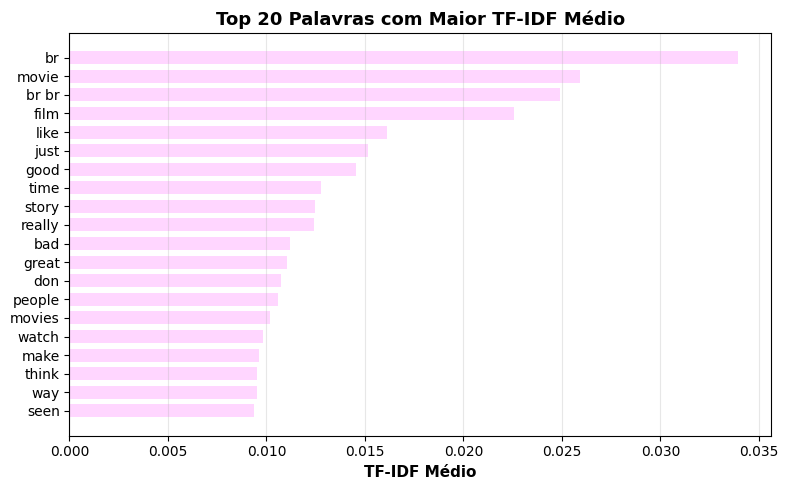

In [73]:
top_n_tfidf = 20
tfidf_means = np.array(X_train_tfidf.mean(axis=0)).flatten()
tfidf_words = vectorizer_tfidf.get_feature_names_out()

top_tfidf_idx = np.argsort(tfidf_means)[-top_n_tfidf:][::-1]
top_tfidf_words = [tfidf_words[i] for i in top_tfidf_idx]
top_tfidf_vals = tfidf_means[top_tfidf_idx]

plt.figure(figsize=(8, 5))
plt.barh(
    range(len(top_tfidf_words)),
    top_tfidf_vals,
    color="#ffd6ff" ,
    linewidth=0.8,
    height=0.7
)

plt.yticks(range(len(top_tfidf_words)), top_tfidf_words, fontsize=10)
plt.xlabel('TF-IDF Médio', fontsize=11, fontweight='bold')
plt.title(f'Top {top_n_tfidf} Palavras com Maior TF-IDF Médio',
          fontsize=13, fontweight='bold')

plt.gca().invert_yaxis()

plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

Número de palavras no vocabulário: 81097
Shape do word_counts: (81097,)


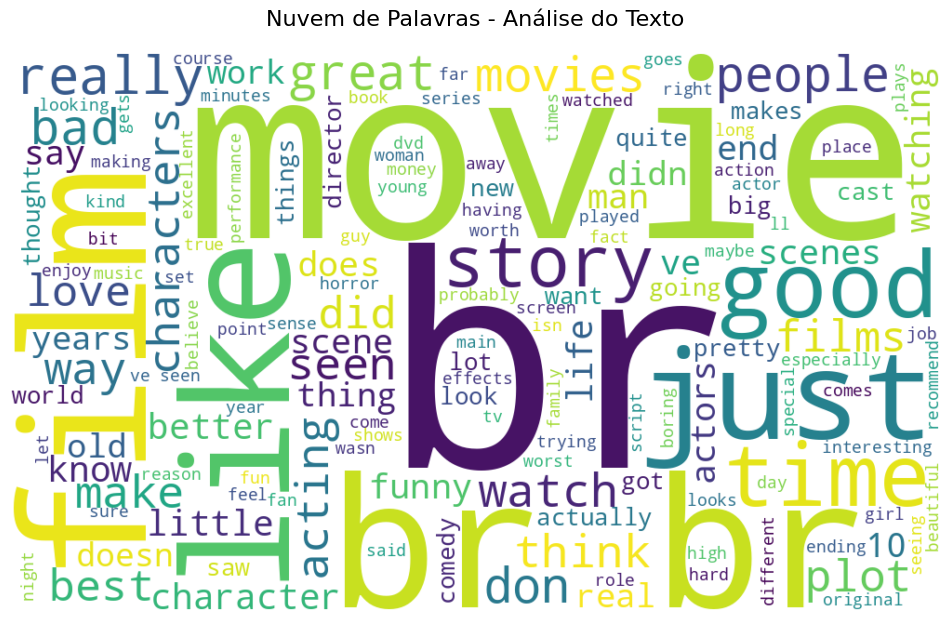

In [74]:
from wordcloud import WordCloud

words = vectorizer_tfidf.get_feature_names_out()  
word_counts = np.array(X_train_tfidf.sum(axis=0)).flatten()  

print(f"Número de palavras no vocabulário: {len(words)}")
print(f"Shape do word_counts: {word_counts.shape}")

freq_dict = dict(zip(words, word_counts))

plt.figure(figsize=(12, 8))
wordcloud = WordCloud(
    width=1000, 
    height=600,
    background_color='white',
    max_words=150,
    colormap='viridis',
    contour_width=1,
    contour_color='steelblue'
).generate_from_frequencies(freq_dict)

plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Nuvem de Palavras - Análise do Texto', fontsize=16, pad=20)
plt.show()

## 1. Regressão Logística (TF-IDF)

In [ ]:
pipeline_lr_tfidf = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1,2), min_df=5, max_df=0.9, sublinear_tf=True)),    
    ("clf", LogisticRegression(max_iter=1000))
])

param_grid_lr_tfidf = {
    "tfidf__ngram_range": [(1,1), (1,2)],
    "tfidf__min_df": [5, 10],
    "tfidf__sublinear_tf": [True, False]
}

grid_lr_tfidf = GridSearchCV(
    pipeline_lr_tfidf,
    param_grid_lr_tfidf,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

grid_lr_tfidf.fit(X_train, y_train)

print("Melhores parâmetros (Logistic Regression + BoW):", grid_lr_tfidf.best_params_)

Melhores parâmetros (Logistic Regression + BoW): {'tfidf__min_df': 10, 'tfidf__ngram_range': (1, 2), 'tfidf__sublinear_tf': True}


In [76]:
y_pred_lr_tfidf = grid_lr_tfidf.predict(X_test)

print("Acurácia:", accuracy_score(y_test, y_pred_lr_tfidf))
print(classification_report(y_test, y_pred_lr_tfidf))

Acurácia: 0.90084
              precision    recall  f1-score   support

           0       0.90      0.90      0.90     12500
           1       0.90      0.91      0.90     12500

    accuracy                           0.90     25000
   macro avg       0.90      0.90      0.90     25000
weighted avg       0.90      0.90      0.90     25000



## 2. LinearSVC (TF-IDF)

In [ ]:
pipeline_svc_tfidf = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1,2), min_df=5, max_df=0.9, sublinear_tf=True)),
    ("clf", LinearSVC())
])

param_grid_svc_tfidf = {
    "tfidf__ngram_range": [(1,1), (1,2)],
    "tfidf__min_df": [5, 10],
    "tfidf__sublinear_tf": [True, False],
    "clf__C": [0.1, 1, 10]
}

grid_svc_tfidf = GridSearchCV(
    pipeline_svc_tfidf,
    param_grid_svc_tfidf,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

grid_svc_tfidf.fit(X_train, y_train)

print("Melhores parâmetros (LinearSVC + TF-IDF):")
print(grid_svc_tfidf.best_params_)


Melhores parâmetros (LinearSVC + TF-IDF):
{'clf__C': 1, 'tfidf__min_df': 5, 'tfidf__ngram_range': (1, 2), 'tfidf__sublinear_tf': True}


In [78]:
y_pred_svc_tfidf = grid_svc_tfidf.predict(X_test)

print("Acurácia:", accuracy_score(y_test, y_pred_svc_tfidf))
print(classification_report(y_test, y_pred_svc_tfidf))

Acurácia: 0.90424
              precision    recall  f1-score   support

           0       0.90      0.91      0.90     12500
           1       0.91      0.90      0.90     12500

    accuracy                           0.90     25000
   macro avg       0.90      0.90      0.90     25000
weighted avg       0.90      0.90      0.90     25000



## 3. Naive Bayes (TF-IDF)

In [ ]:
pipeline_nb_tfidf = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1,2), min_df=5, max_df=0.9, sublinear_tf=True)),
    ("clf", MultinomialNB())
])

param_grid_nb_tfidf = {
    "tfidf__ngram_range": [(1,1), (1,2)],
    "tfidf__min_df": [5, 10],
    "tfidf__sublinear_tf": [True, False],
    "clf__alpha": [0.1, 0.5, 1.0]
}

grid_nb_tfidf = GridSearchCV(
    pipeline_nb_tfidf,
    param_grid_nb_tfidf,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

grid_nb_tfidf.fit(X_train, y_train)

print("Melhores parâmetros (NB + TF-IDF):")
print(grid_nb_tfidf.best_params_)


Melhores parâmetros (NB + TF-IDF):
{'clf__alpha': 0.1, 'tfidf__min_df': 5, 'tfidf__ngram_range': (1, 2), 'tfidf__sublinear_tf': False}


In [80]:
y_pred_nb_tfidf = grid_nb_tfidf.predict(X_test)

print("Acurácia:", accuracy_score(y_test, y_pred_nb_tfidf))
print(classification_report(y_test, y_pred_nb_tfidf))

Acurácia: 0.87008
              precision    recall  f1-score   support

           0       0.85      0.89      0.87     12500
           1       0.89      0.85      0.87     12500

    accuracy                           0.87     25000
   macro avg       0.87      0.87      0.87     25000
weighted avg       0.87      0.87      0.87     25000



In [81]:
resultados = pd.DataFrame({
    "Modelo": [
        "LinearSVC + BoW",
        "LinearSVC + TF-IDF",
        "Naive Bayes + BoW",
        "Naive Bayes + TF-IDF",
        "Regressão Logística + BoW",
        "Regressão Logística + TF-IDF"
    ],
    "Acurácia": [
        accuracy_score(y_test, y_pred_svc_bow),
        accuracy_score(y_test, y_pred_svc_tfidf),
        accuracy_score(y_test, y_pred_nb_bow),
        accuracy_score(y_test, y_pred_nb_tfidf),
        accuracy_score(y_test, y_pred_lr_bow),
        accuracy_score(y_test, y_pred_lr_tfidf)
    ]
})

resultados

,Modelo,Acurácia
0,LinearSVC + BoW,0.88668
1,LinearSVC + TF-IDF,0.90424
2,Naive Bayes + BoW,0.85860
3,Naive Bayes + TF-IDF,0.87008
4,Regressão Logística + BoW,0.89360
5,Regressão Logística + TF-IDF,0.90084


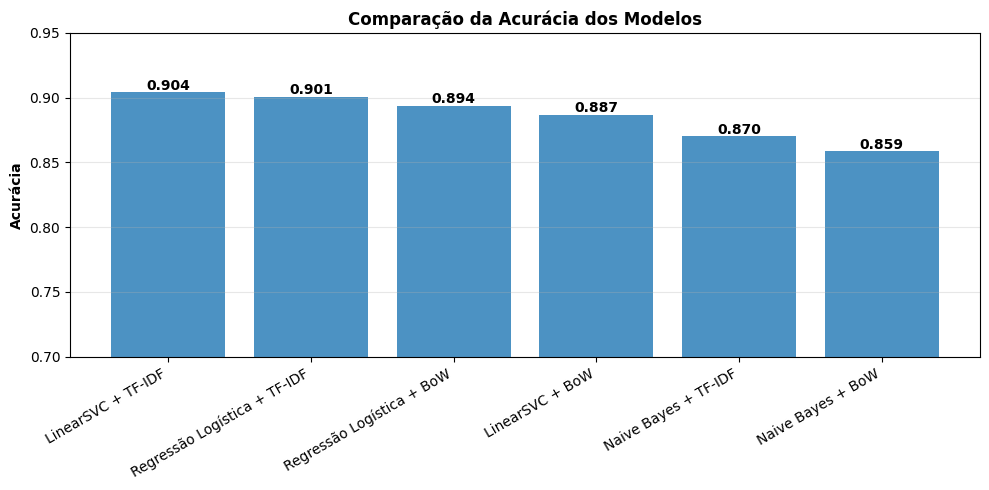

In [82]:
resultados_ord = resultados.sort_values(by="Acurácia", ascending=False)

plt.figure(figsize=(10, 5))
bars = plt.bar(
    resultados_ord["Modelo"],
    resultados_ord["Acurácia"]
)

# Tons pastéis automáticos
for bar in bars:
    bar.set_alpha(0.8)

# Valor em cima da barra
for i, v in enumerate(resultados_ord["Acurácia"]):
    plt.text(
        i,
        v + 0.002,
        f"{v:.3f}",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

plt.ylabel("Acurácia", fontweight="bold")
plt.title("Comparação da Acurácia dos Modelos", fontweight="bold")
plt.xticks(rotation=30, ha="right")
plt.ylim(0.7, 0.95)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

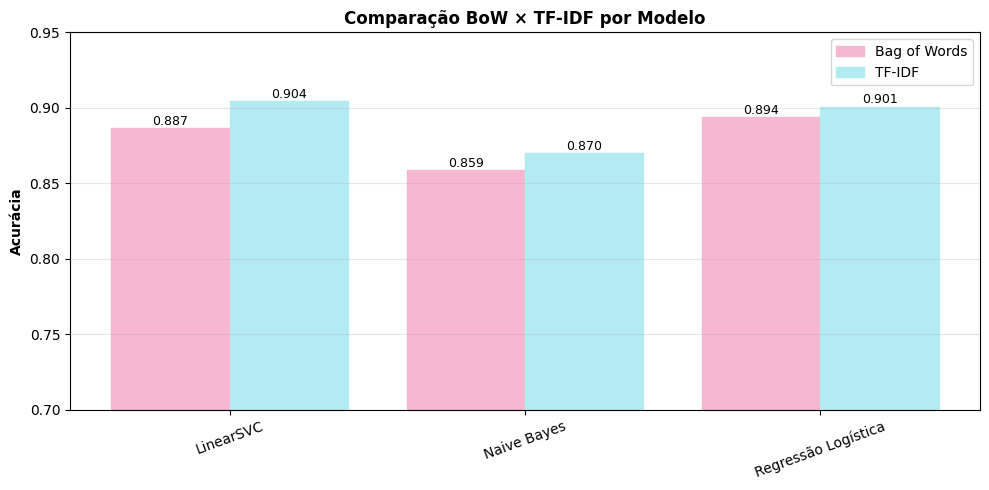

In [85]:
bow = resultados[resultados["Modelo"].str.contains("BoW")]
tfidf = resultados[resultados["Modelo"].str.contains("TF-IDF")]

labels = bow["Modelo"].str.replace(" + BoW", "", regex=False)

x = range(len(labels))

plt.figure(figsize=(10, 5))

plt.bar(
    x,
    bow["Acurácia"],
    width=0.4,
    label="Bag of Words",
)

plt.bar(
    [i + 0.4 for i in x],
    tfidf["Acurácia"],
    width=0.4,
    label="TF-IDF",
)

for bar in plt.gca().containers[0]:
    bar.set_color("#f7b6d2")  

for bar in plt.gca().containers[1]:
    bar.set_color("#B3EBF2")  

for i in x:
    plt.text(i, bow["Acurácia"].iloc[i] + 0.002,
             f"{bow['Acurácia'].iloc[i]:.3f}", ha="center", fontsize=9)
    plt.text(i + 0.4, tfidf["Acurácia"].iloc[i] + 0.002,
             f"{tfidf['Acurácia'].iloc[i]:.3f}", ha="center", fontsize=9)

plt.xticks([i + 0.2 for i in x], labels, rotation=20)
plt.ylabel("Acurácia", fontweight="bold")
plt.title("Comparação BoW × TF-IDF por Modelo", fontweight="bold")
plt.legend()
plt.ylim(0.7, 0.95)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


In [84]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

tabela_metricas = pd.DataFrame({
    "Modelo": [
        "LinearSVC + BoW",
        "LinearSVC + TF-IDF",
        "Naive Bayes + BoW",
        "Naive Bayes + TF-IDF",
        "Regressão Logística + BoW",
        "Regressão Logística + TF-IDF"
    ],
    "Acurácia": [
        accuracy_score(y_test, y_pred_svc_bow),
        accuracy_score(y_test, y_pred_svc_tfidf),
        accuracy_score(y_test, y_pred_nb_bow),
        accuracy_score(y_test, y_pred_nb_tfidf),
        accuracy_score(y_test, y_pred_lr_bow),
        accuracy_score(y_test, y_pred_lr_tfidf)
    ],
    "Precisão": [
        precision_score(y_test, y_pred_svc_bow),
        precision_score(y_test, y_pred_svc_tfidf),
        precision_score(y_test, y_pred_nb_bow),
        precision_score(y_test, y_pred_nb_tfidf),
        precision_score(y_test, y_pred_lr_bow),
        precision_score(y_test, y_pred_lr_tfidf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_svc_bow),
        recall_score(y_test, y_pred_svc_tfidf),
        recall_score(y_test, y_pred_nb_bow),
        recall_score(y_test, y_pred_nb_tfidf),
        recall_score(y_test, y_pred_lr_bow),
        recall_score(y_test, y_pred_lr_tfidf)
    ],
    "F1-score": [
        f1_score(y_test, y_pred_svc_bow),
        f1_score(y_test, y_pred_svc_tfidf),
        f1_score(y_test, y_pred_nb_bow),
        f1_score(y_test, y_pred_nb_tfidf),
        f1_score(y_test, y_pred_lr_bow),
        f1_score(y_test, y_pred_lr_tfidf)
    ]
})

tabela_metricas.iloc[:, 1:] = tabela_metricas.iloc[:, 1:].round(4)

tabela_metricas


,Modelo,Acurácia,Precisão,Recall,F1-score
0,LinearSVC + BoW,0.8867,0.8883,0.8846,0.8864
1,LinearSVC + TF-IDF,0.9042,0.9061,0.9019,0.9040
2,Naive Bayes + BoW,0.8586,0.8830,0.8267,0.8539
3,Naive Bayes + TF-IDF,0.8701,0.8881,0.8469,0.8670
4,Regressão Logística + BoW,0.8936,0.8931,0.8942,0.8937
5,Regressão Logística + TF-IDF,0.9008,0.8972,0.9054,0.9013


In [ ]:
modelo_lr = grid_lr_tfidf.best_estimator_

vectorizer = modelo_lr.named_steps["tfidf"]

clf = modelo_lr.named_steps["clf"]

feature_names = np.array(vectorizer.get_feature_names_out())


In [ ]:
coef = clf.coef_[0]

top_n = 15

# Mais negativas
top_neg_idx = np.argsort(coef)[:top_n]
top_neg_words = feature_names[top_neg_idx]
top_neg_values = coef[top_neg_idx]

# Mais positivas
top_pos_idx = np.argsort(coef)[-top_n:]
top_pos_words = feature_names[top_pos_idx]
top_pos_values = coef[top_pos_idx]

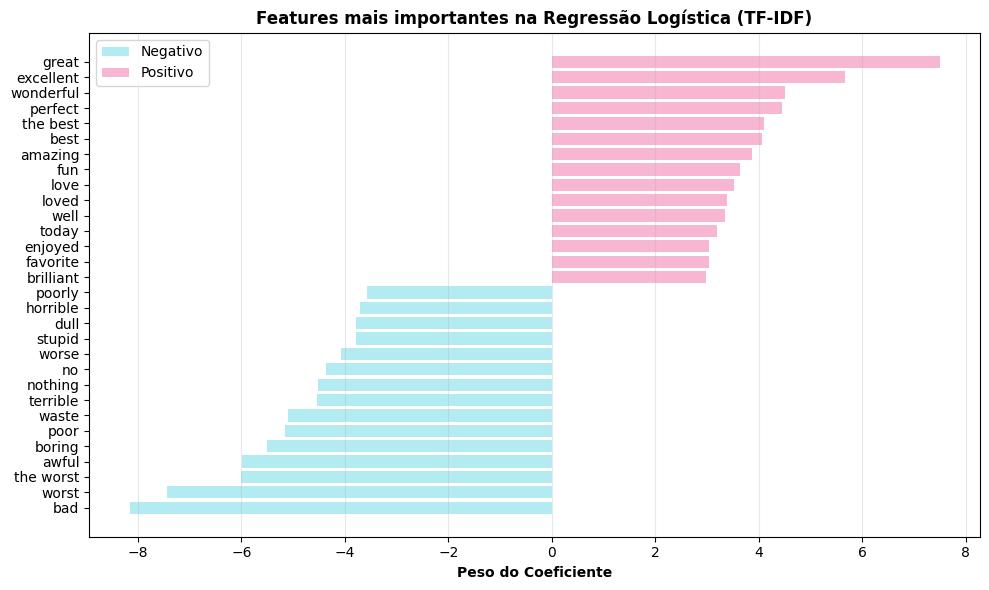

In [ ]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_neg_words,
    top_neg_values,
    color="#B3EBF2",
    label="Negativo"
)

plt.barh(
    top_pos_words,
    top_pos_values,
    color="#f7b6d2",
    label="Positivo"
)

plt.xlabel("Peso do Coeficiente", fontweight="bold")
plt.title(
    "Features mais importantes na Regressão Logística (TF-IDF)",
    fontweight="bold"
)

plt.legend()
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()
